In [233]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import matplotlib.ticker as mtick

In [234]:
df = pd.read_csv("emissions.csv", sep =",")
n_cases = 4
n_materials = 6

df

,Category,Initial_PA.Nylon,Initial_PA_return,Targeted_PA.Nylon,Targeted_PA_return,Incentive_PA.Nylon,Incentive_PA_return,Normal_PA.Nylon,Normal_PA_return,Initial_PES,...,Normal_CO_return,Initial_LI_Flax,Initial_LI_return,Targeted_LI_Flax,Targeted_LI_return,Incentive_LI_Flax,Incentive_LI_return,Normal_LI_Flax,Normal_LI_return,Unit
0,"Climate change, incl biogenic carbon",9597.959,7085.040,9445.184,7015.472,9031.978,6731.090,9521.986,7036.941,145511.865,...,602.020,74.784,53.224,74.784,53.224,73.406,52.536,74.094,52.536,kg CO2-Eq.
1,Freshwater aquatic ecotoxicity,35.533,26.230,34.968,25.973,33.438,24.920,35.252,26.052,4724.477,...,59.224,3.974,2.828,3.974,2.828,3.901,2.792,3.937,2.792,kg 1.4 DCB eq.
2,Marine aquatic ecotoxicity,49.000,36.171,48.220,35.815,46.110,34.364,48.612,35.925,6315.233,...,48.337,4.588,3.265,4.588,3.265,4.503,3.223,4.546,3.223,kg 1.4 DCB eq.
3,Terrestrial ecotoxicity,2257.508,1666.452,2221.574,1650.089,2124.385,1583.200,2239.639,1655.138,535417.090,...,2052.612,317.894,226.248,317.894,226.248,312.039,223.323,314.964,223.323,kg 1.4 DCB eq.
4,Freshwater Eutrophication,0.500,0.369,0.492,0.366,0.471,0.351,0.496,0.367,37.767,...,0.558,0.025,0.018,0.025,0.018,0.024,0.018,0.025,0.018,kg P eq.
5,Marine Eutrophication,2.778,2.050,2.734,2.030,2.614,1.948,2.756,2.037,12.895,...,5.449,0.252,0.179,0.252,0.179,0.247,0.177,0.249,0.177,kg N eq.
6,Terrestrial Acidification,27.144,20.037,26.712,19.840,25.543,19.036,26.929,19.901,403.199,...,7.421,1.080,0.769,1.080,0.769,1.060,0.759,1.070,0.759,kg SO2 eq.
7,Photochemical Ozone Formation. Ecosystems,17.234,12.722,16.960,12.597,16.218,12.087,17.098,12.636,383.569,...,2.402,0.356,0.253,0.356,0.253,0.350,0.250,0.353,0.250,kg NOx eq.
8,lonizing Radiation,1.743,1.287,1.715,1.274,1.640,1.222,1.729,1.278,7296.447,...,8.412,1.519,1.081,1.519,1.081,1.491,1.067,1.505,1.067,kBq Co-60 eq.
9,"Human toxicity, cancer",181.077,133.668,178.195,132.355,170.399,126.990,179.644,132.761,7198.569,...,25.960,3.746,2.666,3.746,2.666,3.677,2.631,3.711,2.631,kg 1.4-DB eq.


In [235]:
#df = df[df.Category.isin(["Climate change, incl biogenic carbon",
#"Freshwater aquatic ecotoxicity",
#"Terrestrial ecotoxicity",
#"Human toxicity, cancer",
#"Human toxicity, non-cancer",
#"Fossil depletion"])].reset_index()
#df.Category = df.Category.str.replace(',', '\n')
#df.Category = df.Category + " in " + df.Unit
df = df.reset_index()

In [236]:
materials = [string.rsplit("_", 1)[1] for string in df.columns[list(range(2, len(df.columns)-1, 8))]]
cases = [string.rsplit("_", 1)[0] for string in df.columns[list(range(2, 9, 2))]]
df

,index,Category,Initial_PA.Nylon,Initial_PA_return,Targeted_PA.Nylon,Targeted_PA_return,Incentive_PA.Nylon,Incentive_PA_return,Normal_PA.Nylon,Normal_PA_return,...,Normal_CO_return,Initial_LI_Flax,Initial_LI_return,Targeted_LI_Flax,Targeted_LI_return,Incentive_LI_Flax,Incentive_LI_return,Normal_LI_Flax,Normal_LI_return,Unit
0,0,"Climate change, incl biogenic carbon",9597.959,7085.040,9445.184,7015.472,9031.978,6731.090,9521.986,7036.941,...,602.020,74.784,53.224,74.784,53.224,73.406,52.536,74.094,52.536,kg CO2-Eq.
1,1,Freshwater aquatic ecotoxicity,35.533,26.230,34.968,25.973,33.438,24.920,35.252,26.052,...,59.224,3.974,2.828,3.974,2.828,3.901,2.792,3.937,2.792,kg 1.4 DCB eq.
2,2,Marine aquatic ecotoxicity,49.000,36.171,48.220,35.815,46.110,34.364,48.612,35.925,...,48.337,4.588,3.265,4.588,3.265,4.503,3.223,4.546,3.223,kg 1.4 DCB eq.
3,3,Terrestrial ecotoxicity,2257.508,1666.452,2221.574,1650.089,2124.385,1583.200,2239.639,1655.138,...,2052.612,317.894,226.248,317.894,226.248,312.039,223.323,314.964,223.323,kg 1.4 DCB eq.
4,4,Freshwater Eutrophication,0.500,0.369,0.492,0.366,0.471,0.351,0.496,0.367,...,0.558,0.025,0.018,0.025,0.018,0.024,0.018,0.025,0.018,kg P eq.
5,5,Marine Eutrophication,2.778,2.050,2.734,2.030,2.614,1.948,2.756,2.037,...,5.449,0.252,0.179,0.252,0.179,0.247,0.177,0.249,0.177,kg N eq.
6,6,Terrestrial Acidification,27.144,20.037,26.712,19.840,25.543,19.036,26.929,19.901,...,7.421,1.080,0.769,1.080,0.769,1.060,0.759,1.070,0.759,kg SO2 eq.
7,7,Photochemical Ozone Formation. Ecosystems,17.234,12.722,16.960,12.597,16.218,12.087,17.098,12.636,...,2.402,0.356,0.253,0.356,0.253,0.350,0.250,0.353,0.250,kg NOx eq.
8,8,lonizing Radiation,1.743,1.287,1.715,1.274,1.640,1.222,1.729,1.278,...,8.412,1.519,1.081,1.519,1.081,1.491,1.067,1.505,1.067,kBq Co-60 eq.
9,9,"Human toxicity, cancer",181.077,133.668,178.195,132.355,170.399,126.990,179.644,132.761,...,25.960,3.746,2.666,3.746,2.666,3.677,2.631,3.711,2.631,kg 1.4-DB eq.


In [242]:
# Summed up totals over materials per case
total_sums = df.Category

# Summed up returns materials per case
return_sums = df.Category

totals = df.Category

cat1 = pd.DataFrame(columns= ["Scenario"] + materials)
cat1['Scenario'] = cases

for i in range(2, 9, 2):
    total_sums = pd.concat([total_sums, 
                            df.iloc[:, [index for index in range(i, len(df.columns)-1, 8)]].sum(axis=1)], 
                           axis = 1)
    totals = pd.concat([totals, 
                            df.iloc[:, [index for index in range(i, len(df.columns)-1, 8)]]], 
                           axis = 1)
    
    # cat1.iloc[int(i/2-1), 1:] = totals.iloc[0,int(((i/2-1)*len(materials)+1)):int(((i/2-1)*len(materials))+len(materials)+1)]
    
    return_sums = pd.concat([return_sums, 
                            df.iloc[:, [index for index in range(i+1, len(df.columns)-1, 8)]].sum(axis=1)], 
                           axis = 1)

total_sums.columns.values[1:] = cases
return_sums.columns.values[1:] = cases

materials_sum = df.Category

# Get Summed up Materials
for i in range(2, len(df.columns)-1, 8):
    materials_sum = pd.concat([materials_sum,
               df.iloc[:, [index for index in range(i, i+8, 2)]].sum(axis=1)], axis = 1)

materials_sum.columns.values[1:] = materials

materials_sum.iloc[:, 1:] = materials_sum.iloc[:, 1:].div(materials_sum.iloc[:, 1:].sum(axis=1), axis='index')*100

total_sums.join(df.Unit).iloc[:, [0, 1, -1]].to_csv("totals_sums.csv", index=False)

In [238]:
font = {'family' : 'sans-serif',
'weight' : 'normal',
'size'   : 15}
plt.rc('font', **font)
 
def apply_plot_layout(ax,Grid=True):
 
    #_______LABEL
    #ax.set_ylabel("defect found")
    #ax.set_xlabel(r"time [s]")
    ax.tick_params(direction='in')
    #ax.set_yticks=([0,1])
 
    #_______LEGEND
    #ax.legend(loc="best",fontsize=8, framealpha=0.5,ncol=1,fancybox=True)
    #ax.legend(loc='lower left',fontsize=10, framealpha=0.9,ncol=1)
 
    #_________GRID
    #plt.grid(linestyle=(0, (1, 10)), linewidth=1, alpha=0.5)
    ax.grid(linestyle=':',linewidth=1, alpha=0.5)
    if Grid==False: 
        ax.grid(False)
 
 
    #______SET ASPECT
    #axisratio=(1+np.sqrt(5))/2
    #axisratio=1.5
    #y_min, y_max = ax.get_ylim()
    #x_min, x_max = ax.get_xlim()
    #ax.set_aspect((x_max-x_min)/(y_max-y_min)/axisratio, adjustable='box')
    
    #_______AXES LINEWIDTH
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.3)
    #plt.tight_layout(pad=0.5)
    return

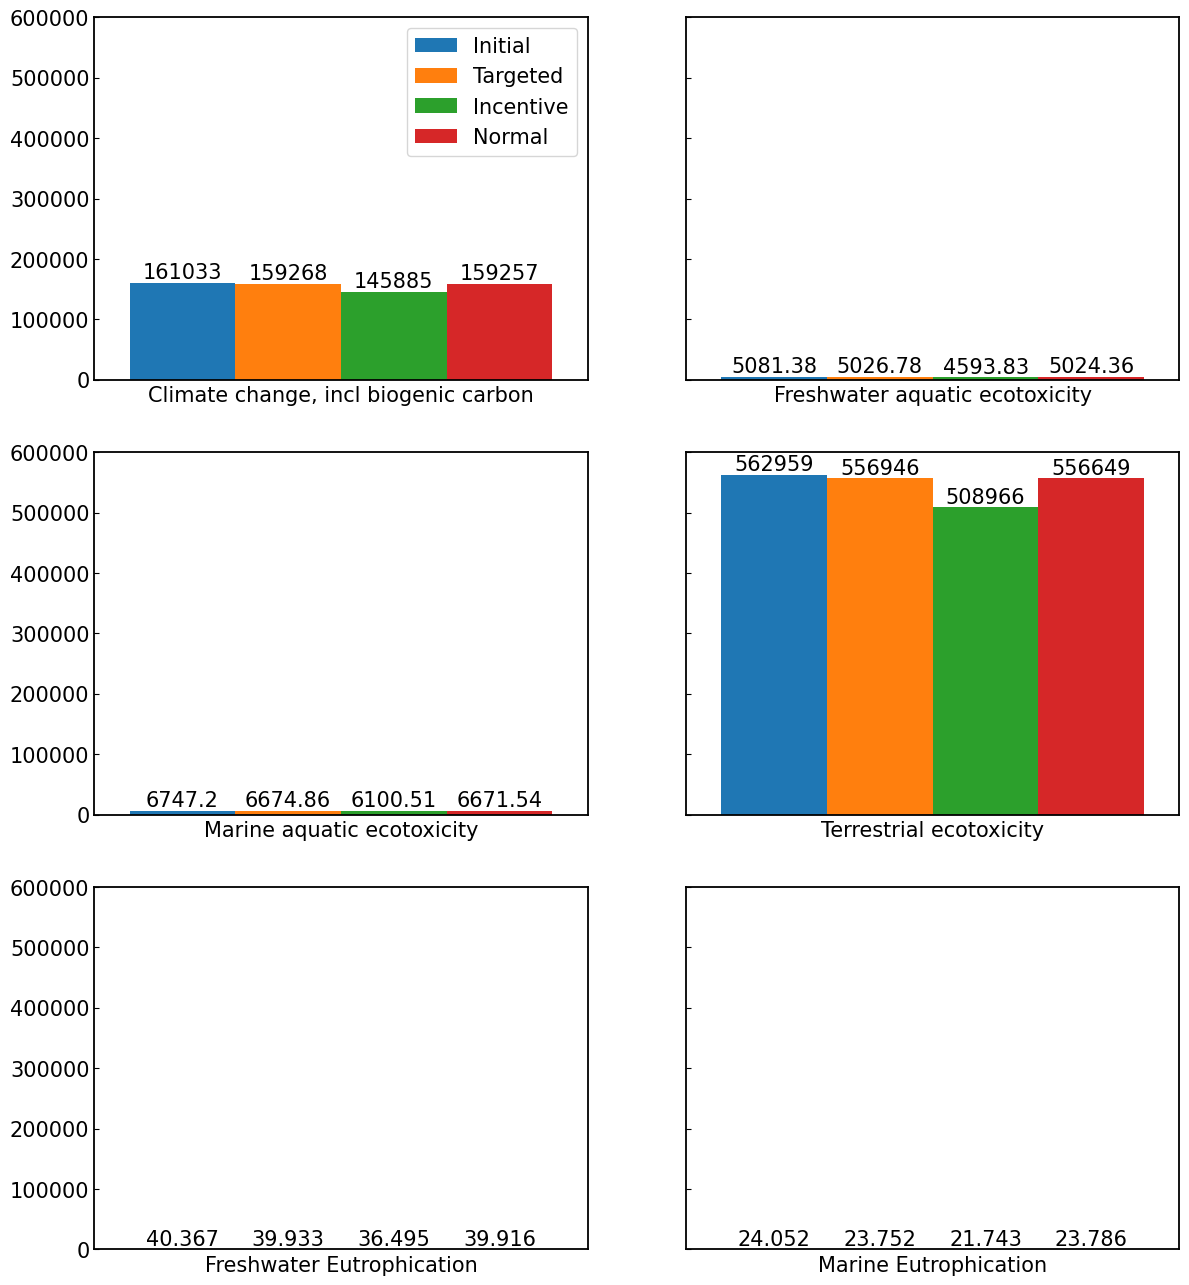

In [239]:
# total_sums.plot.bar(logy = True, x='Category', stacked = False, rot=15, figsize=(15,5))
# total_sums.sort_values(by=['col1'])

nrows = 3
ncols = 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharey=True, figsize=(14, 16))
i = 0
legend = True
for row in range(nrows):
    for col in range(ncols):
        if i == 1:
            legend = False
        ax = axes[row, col]
        apply_plot_layout(ax)
        total_sums.iloc[i, :].to_frame().T.plot.bar(ax=ax, 
                                                    xlabel=total_sums.iloc[i, 0], 
                                                    xticks= [], 
                                                    rot = 0, 
                                                    stacked = False, 
                                                    legend = legend,
                                                    ylim = (0, 600000),
                                                    width = 3)
        for container in ax.containers:
            ax.bar_label(container)
        i+=1

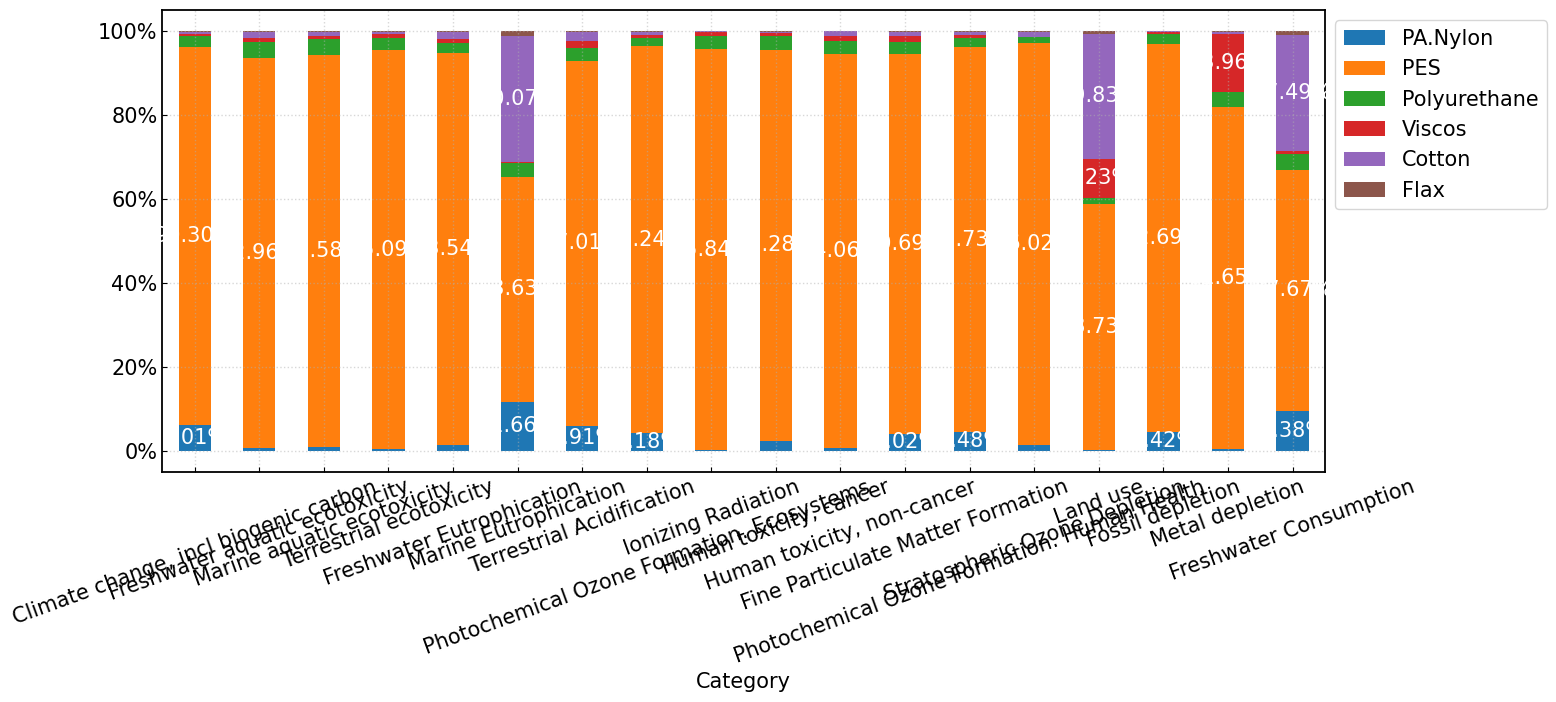

In [240]:
ax = materials_sum.plot.bar(stacked = True, x = "Category", rot=20, figsize=(15,6))
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(bbox_to_anchor=(1.0, 1.0))
apply_plot_layout(ax)

labels = [f'{i/100:.2%}' if i >= 4 else "" for i in materials_sum.iloc[:, 1:].to_numpy().flatten(order='F')]

for i, patch in enumerate(ax.patches):
    x, y = patch.get_xy()
    x += patch.get_width() / 2
    y += patch.get_height() / 2
    ax.annotate(labels[i], (x, y), ha='center', va='center', c='white')